# SVM Task

Classes: The dataset has two target classes:
Malignant (denoted by 0)
Benign (denoted by 1)

- radius_mean: Mean of distances from the center to points on the perimeter.
- texture_mean: Standard deviation of gray-scale values.
- perimeter_mean: Mean of perimeter values.
- area_mean: Mean of area values.
- smoothness_mean: Mean of local variation in radius lengths.
- compactness_mean: Mean of perimeter^2 / area - 1.0
- concavity_mean: Mean of severity of concave portions of the contour.
- concave points_mean: Mean for the number of concave portions of the contour.
- symmetry_mean: Mean of symmetry.
- fractal_dimension_mean: Mean of the "coastline approximation" - 1.
- radius_se: Standard error for radius.
- texture_se: Standard error for texture.
- perimeter_se: Standard error for perimeter.
- area_se: Standard error for area.
- smoothness_se: Standard error for smoothness.
- compactness_se: Standard error for compactness.
- concavity_se: Standard error for concavity.
- concave points_se: Standard error for concave points.
- symmetry_se: Standard error for symmetry.
- fractal_dimension_se: Standard error for fractal dimension.
- radius_worst: Worst or largest radius value.
- texture_worst: Worst texture value.
- perimeter_worst: Worst perimeter value.
- area_worst: Worst area value.
- smoothness_worst: Worst smoothness value.
- compactness_worst: Worst compactness value.
- concavity_worst: Worst concavity value.
- concave points_worst: Worst concave points value.
- symmetry_worst: Worst symmetry value.
- fractal_dimension_worst: Worst fractal dimension value.

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.feature_selection import f_classif
from svm_margin_plot import plot_svm_boundary
import time
import warnings
warnings.filterwarnings('ignore')

In [58]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Assign the correct column names based on the dataset documentation
columns = ['ID', 'Diagnosis'] + [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean',
    'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se',
    'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst',
    'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst',
    'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Load the dataset and assign these column names
data = pd.read_csv(url, header=None, names=columns)
data.drop(columns=['ID'], inplace=True)


In [4]:
data.head()

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
data.Diagnosis.value_counts()

,count
Diagnosis,
B,357
M,212


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [7]:
data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## First Task

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
encoder = LabelEncoder()
target = data['Diagnosis']
target

,Diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


In [10]:
target = encoder.fit_transform(target)
target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [11]:
target = pd.DataFrame(target,
                      columns = ['Diagnosis'])

In [12]:
target

,Diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


In [13]:
data[target.columns] = target

data.head(10)

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,1,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,1,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,1,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [14]:
data.Diagnosis.value_counts()
# "0" ---> "B"
# "1" ---> "M"

,count
Diagnosis,
0,357
1,212


In [15]:
X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

In [16]:
X.shape

(569, 30)

In [17]:
select_best = SelectKBest(f_classif, k=2)
X_new = select_best.fit_transform(X, y)
X.columns[select_best.get_support()]

Index(['perimeter_worst', 'concave points_worst'], dtype='object')

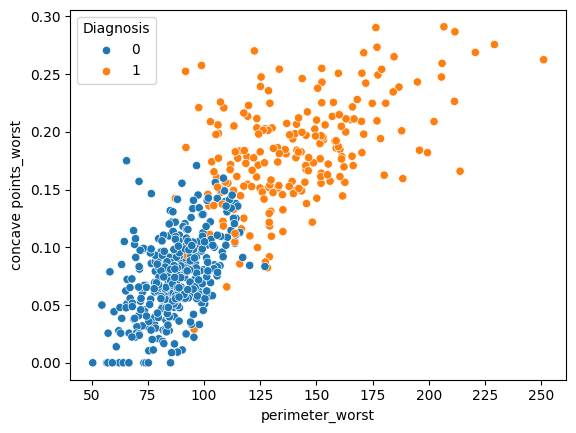

In [18]:
sns.scatterplot(x ='perimeter_worst' ,y= 'concave points_worst',hue='Diagnosis',data=data)
plt.show()

In [19]:
svm = SVC(kernel='linear')

rfe = RFE(estimator=svm, n_features_to_select=2)

X_new = rfe.fit_transform(X, y)

In [20]:
X.columns[rfe.get_support()]

Index(['concavity_worst', 'concave points_worst'], dtype='object')

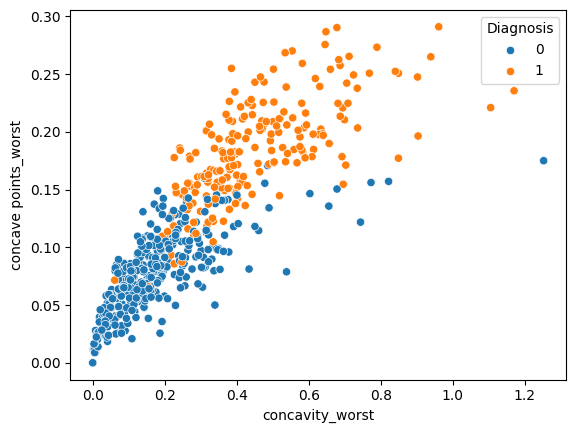

In [21]:
sns.scatterplot(x ='concavity_worst' ,y= 'concave points_worst',hue='Diagnosis',data=data)
plt.show()

In [22]:
# based on the comparison between the 2 feature selection approaches I choose the ['concavity_worst', 'concave points_worst'] as the features seems far from each other as possible and that can be classified into 2 categories that helps apply SVM / Logistic regression

In [23]:
X_new = X[['perimeter_worst', 'concave points_worst']]

In [24]:
X_new

,perimeter_worst,concave points_worst
0,184.60,0.2654
1,158.80,0.1860
2,152.50,0.2430
3,98.87,0.2575
4,152.20,0.1625
...,...,...
564,166.10,0.2216
565,155.00,0.1628
566,126.70,0.1418
567,184.60,0.2650


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

In [26]:
lr = LogisticRegression()

In [27]:
lr.fit(X_train, y_train)

LogisticRegression()

In [28]:
y_pred = lr.predict(X_test)

In [29]:
print(f"Logistic Regression model Accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred)}")

Logistic Regression model Accuracy: 0.9649122807017544


In [30]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print(f"SVM model Accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred)}")

SVM model Accuracy: 0.9649122807017544


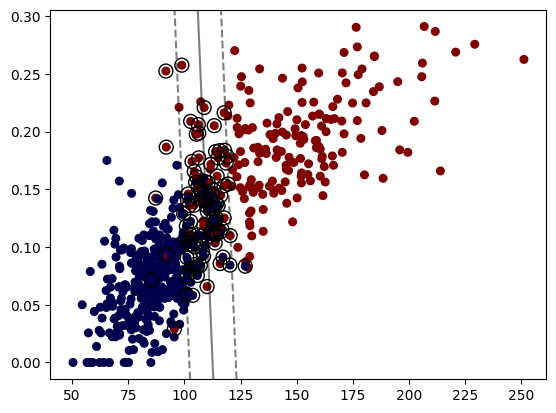

In [31]:
plot_svm_boundary(svm, X_new, y)

## Second Task

In [32]:
X = data.drop(['Diagnosis'], axis=1)
y = data[['Diagnosis']]

In [33]:
X1, X_test, y1 ,y_test = train_test_split(X, y, test_size=0.121, random_state=42)

In [34]:
X1.shape, X_test.shape

((500, 30), (69, 30))

In [35]:
X_train, X_val, y_train, y_val = train_test_split(X1,y1, test_size=0.2, random_state=42)

In [36]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((400, 30), (100, 30), (400, 1), (100, 1))

In [37]:
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
147,14.950,18.77,97.84,689.5,0.08138,0.11670,0.09050,0.03562,0.1744,0.06493,...,16.25,25.47,107.10,809.7,0.09970,0.2521,0.2500,0.08405,0.2852,0.09218
445,11.990,24.89,77.61,441.3,0.10300,0.09218,0.05441,0.04274,0.1820,0.06850,...,12.98,30.36,84.48,513.9,0.13110,0.1822,0.1609,0.12020,0.2599,0.08251
382,12.050,22.72,78.75,447.8,0.06935,0.10730,0.07943,0.02978,0.1203,0.06659,...,12.57,28.71,87.36,488.4,0.08799,0.3214,0.2912,0.10920,0.2191,0.09349
505,9.676,13.14,64.12,272.5,0.12550,0.22040,0.11880,0.07038,0.2057,0.09575,...,10.60,18.04,69.47,328.1,0.20060,0.3663,0.2913,0.10750,0.2848,0.13640
85,18.460,18.52,121.10,1075.0,0.09874,0.10530,0.13350,0.08795,0.2132,0.06022,...,22.93,27.68,152.20,1603.0,0.13980,0.2089,0.3157,0.16420,0.3695,0.08579


In [38]:
scaler = StandardScaler()

In [39]:
X_train = pd.DataFrame(scaler.fit_transform(X_train),
                       columns=X_train.columns)

X_val = pd.DataFrame(scaler.transform(X_val),
                     columns=X_val.columns)

X_test = pd.DataFrame(scaler.transform(X_test),
                     columns=X_test.columns)

In [40]:
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.237085,-0.144893,0.245916,0.098282,-1.044273,0.239233,0.015709,-0.341392,-0.240630,0.283861,...,-0.000447,-0.060143,-0.002108,-0.121139,-1.375559,-0.005165,-0.108222,-0.460999,-0.073987,0.429973
1,-0.600468,1.244993,-0.586554,-0.595613,0.484148,-0.228862,-0.441008,-0.152174,0.029611,0.774955,...,-0.674966,0.713190,-0.673838,-0.630710,-0.046064,-0.450358,-0.533219,0.090698,-0.470337,-0.084976
2,-0.583491,0.752174,-0.539642,-0.577441,-1.894730,0.059784,-0.124381,-0.496593,-2.164322,0.512213,...,-0.759538,0.452250,-0.588313,-0.674639,-1.871368,0.436206,0.088298,-0.077176,-1.109511,0.499733
3,-1.255231,-1.423498,-1.141671,-1.067529,2.074779,2.218903,0.373844,0.582376,0.872337,4.523498,...,-1.165900,-1.235167,-1.119579,-0.950786,2.896608,0.722174,0.088775,-0.103121,-0.080253,2.784786
4,1.230265,-0.201670,1.203071,1.176028,0.182988,0.021603,0.559872,1.049309,1.139023,-0.364052,...,1.377469,0.289359,1.337193,1.245471,0.322299,-0.280306,0.205160,0.762197,1.246659,0.089691


In [41]:
tempFrame = X_train.reset_index(drop=True)

In [42]:
tempFrame['Diagnosis'] = y_train.reset_index(drop=True)

In [43]:
tempFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              400 non-null    float64
 1   texture_mean             400 non-null    float64
 2   perimeter_mean           400 non-null    float64
 3   area_mean                400 non-null    float64
 4   smoothness_mean          400 non-null    float64
 5   compactness_mean         400 non-null    float64
 6   concavity_mean           400 non-null    float64
 7   concave points_mean      400 non-null    float64
 8   symmetry_mean            400 non-null    float64
 9   fractal_dimension_mean   400 non-null    float64
 10  radius_se                400 non-null    float64
 11  texture_se               400 non-null    float64
 12  perimeter_se             400 non-null    float64
 13  area_se                  400 non-null    float64
 14  smoothness_se            4

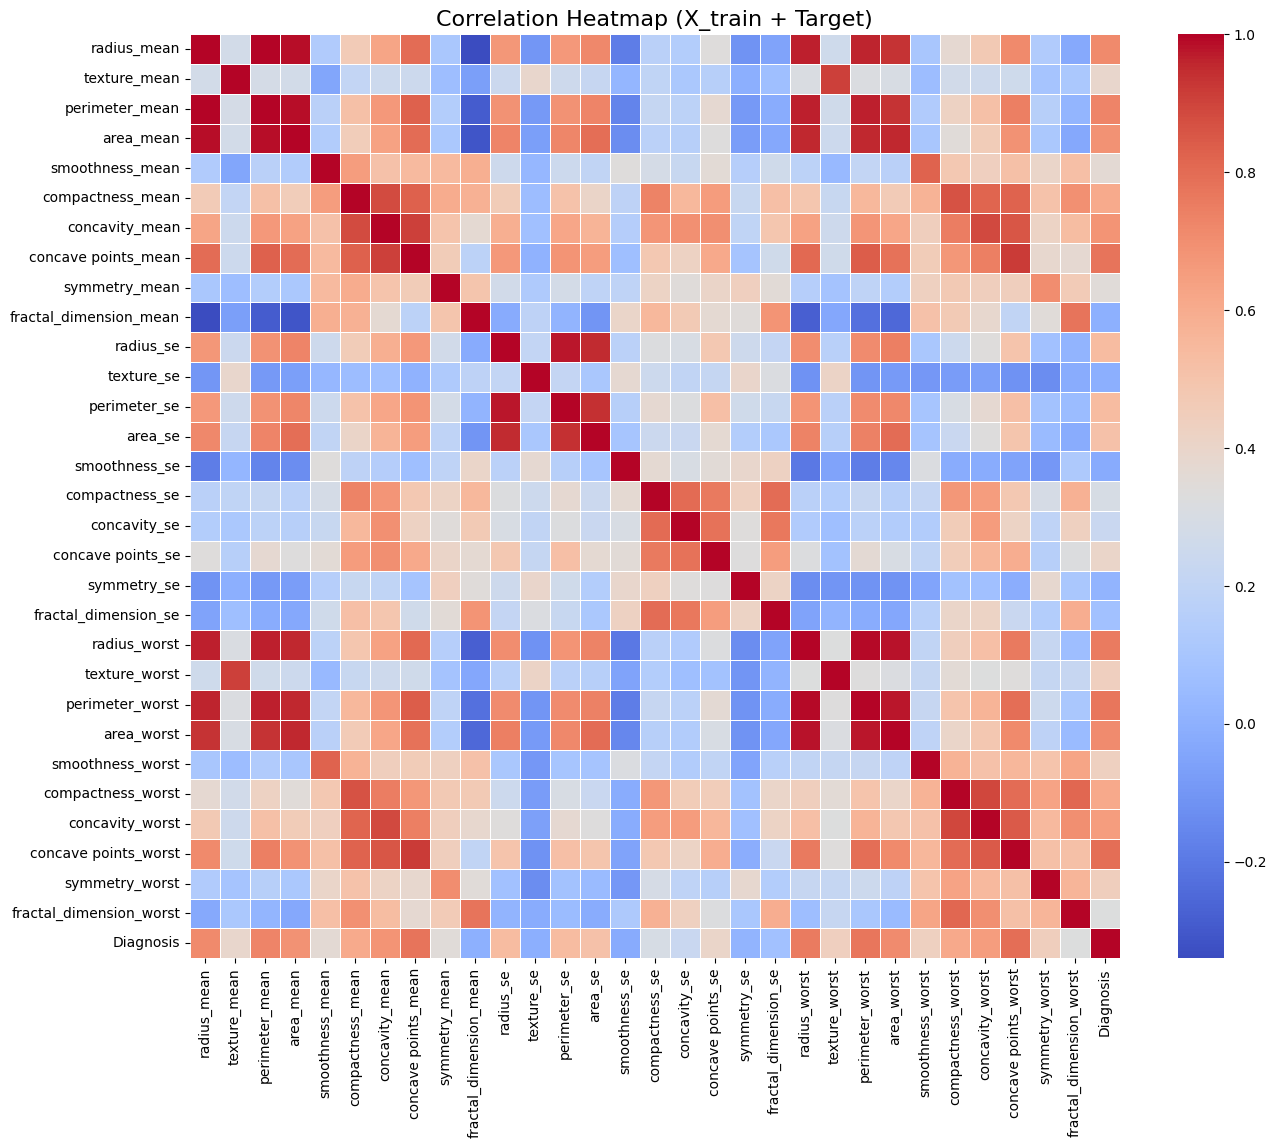

In [44]:
corr = tempFrame.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap (X_train + Target)", fontsize=16)
plt.show()

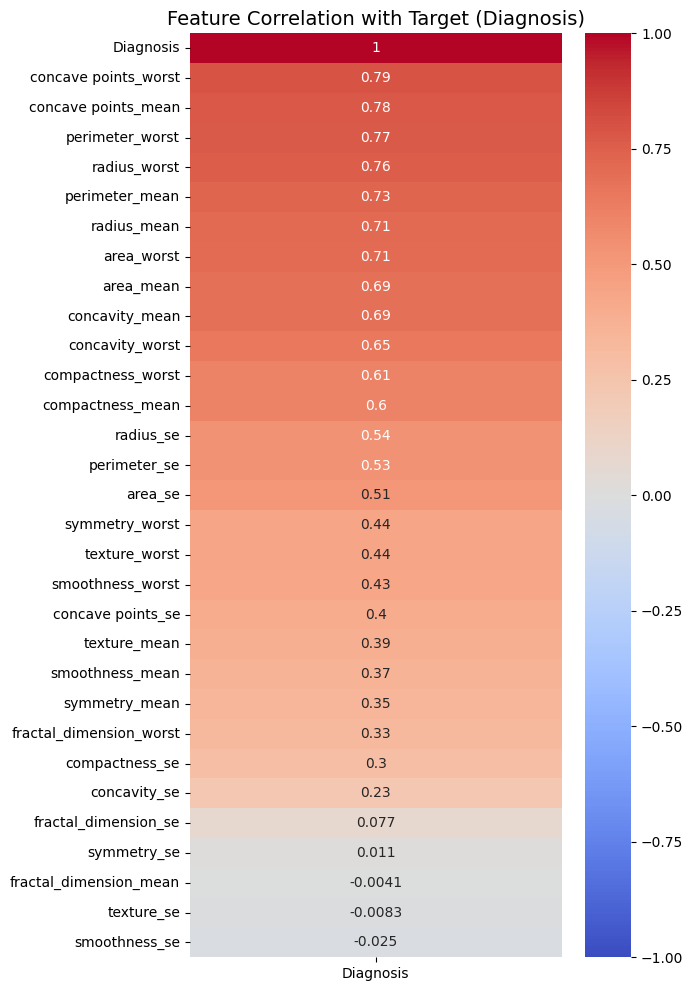

In [45]:
corr_with_target = tempFrame.corr()[["Diagnosis"]].sort_values(by="Diagnosis", ascending=False)

plt.figure(figsize=(6, 12))
sns.heatmap(corr_with_target, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation with Target (Diagnosis)", fontsize=14)
plt.show()

In [46]:
select_best = SelectKBest(f_classif, k=2)
X_new = select_best.fit_transform(X_train, y_train)
X_train.columns[select_best.get_support()]

Index(['concave points_mean', 'concave points_worst'], dtype='object')

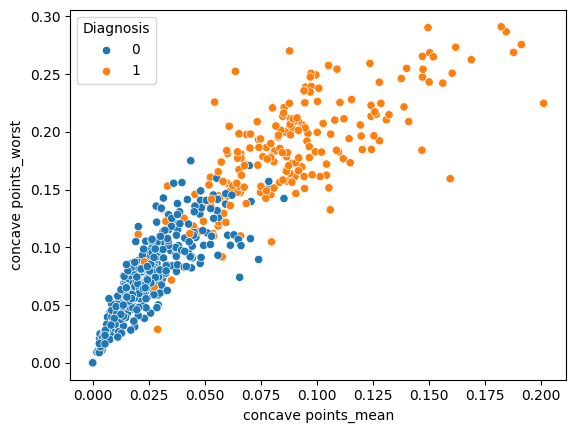

In [47]:
sns.scatterplot(x ='concave points_mean' ,y= 'concave points_worst',hue='Diagnosis',data=data)
plt.show()

In [48]:
X1 = X1[['concave points_mean','concave points_worst']]
X1.head()

,concave points_mean,concave points_worst
331,0.02950,0.09858
196,0.06526,0.16730
11,0.06606,0.18100
395,0.03251,0.07911
177,0.08866,0.20350


In [49]:
X_train = X_train[['concave points_mean','concave points_worst']]
X_train.head()

,concave points_mean,concave points_worst
0,-0.341392,-0.460999
1,-0.152174,0.090698
2,-0.496593,-0.077176
3,0.582376,-0.103121
4,1.049309,0.762197


In [50]:
X_val = X_val[['concave points_mean','concave points_worst']]
X_test = X_test[['concave points_mean','concave points_worst']]

In [51]:
svmL = SVC(kernel='linear')
svmL.fit(X_train, y_train)
y_pred_val = svmL.predict(X_val)
y_pred_test = svmL.predict(X_test)


print(f"SVML model Validation Accuracy: {accuracy_score(y_true=y_val, y_pred=y_pred_val)}")
print(f"SVML model test Accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred_test)}")


SVML model Validation Accuracy: 0.92
SVML model test Accuracy: 0.9565217391304348


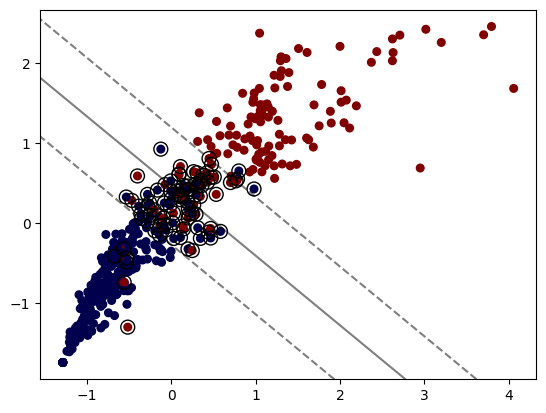

In [52]:
plot_svm_boundary(svmL, X_train, y_train)

In [53]:
svmR = SVC(kernel='rbf')
svmR.fit(X_train, y_train)
y_pred_val = svmR.predict(X_val)
y_pred_test = svmR.predict(X_test)

print(f"SVMR model Validation Accuracy: {accuracy_score(y_true=y_val, y_pred=y_pred_val)}")
print(f"SVMR model test Accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred_test)}")


SVMR model Validation Accuracy: 0.92
SVMR model test Accuracy: 0.9420289855072463


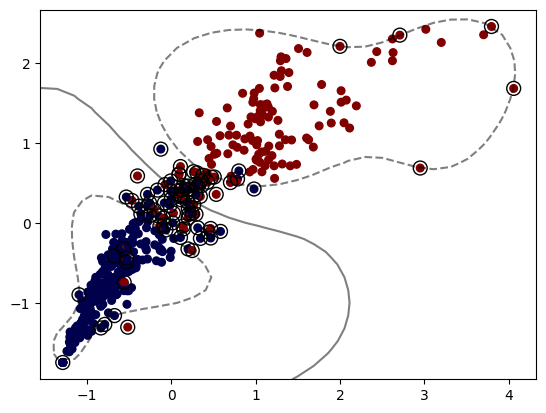

In [54]:
plot_svm_boundary(svmR, X_train, y_train)

In [55]:
svmP = SVC(kernel='poly')
svmP.fit(X_train, y_train)
y_pred_val = svmP.predict(X_val)
y_pred_test = svmP.predict(X_test)


print(f"SVMP model Validation Accuracy: {accuracy_score(y_true=y_val, y_pred=y_pred_val)}")
print(f"SVMP model test Accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred_test)}")


SVMP model Validation Accuracy: 0.89
SVMP model test Accuracy: 0.8985507246376812


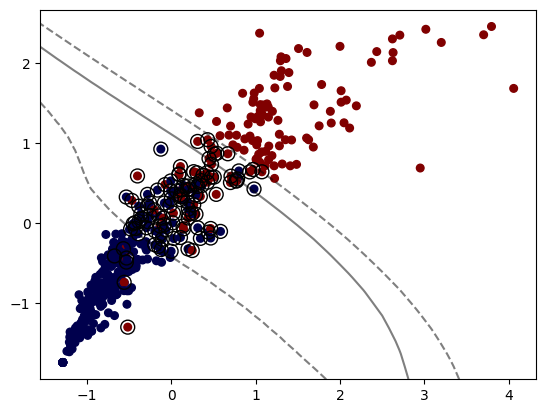

In [56]:
plot_svm_boundary(svmP, X_train, y_train)

In [61]:
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]

In [62]:
results = {}

for C in C_values:
    for gamma in gamma_values:
        model = SVC(kernel="linear", C=C, gamma=gamma)
        model.fit(X_train, y_train)
        y_pred_val = model.predict(X_val)
        acc = accuracy_score(y_val, y_pred_val)
        results[(C, gamma)] = acc

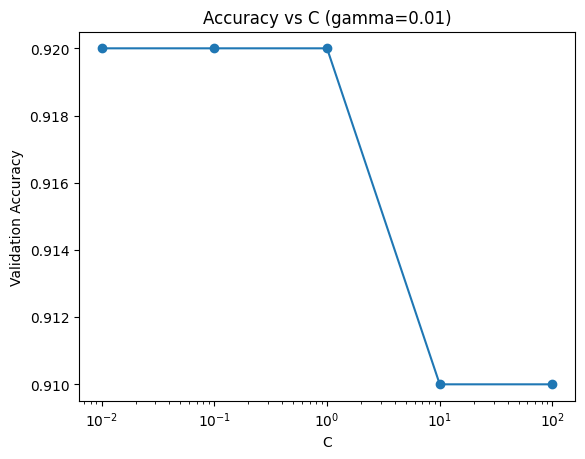

In [63]:
gamma_fixed = 0.01
scores_C = [results[(C, gamma_fixed)] for C in C_values]

plt.plot(C_values, scores_C, marker='o')
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title(f"Accuracy vs C (gamma={gamma_fixed})")
plt.show()

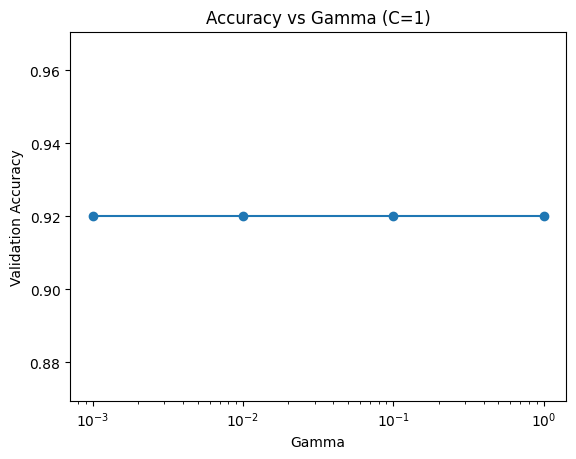

In [64]:
C_fixed = 1
scores_gamma = [results[(C_fixed, g)] for g in gamma_values]

plt.plot(gamma_values, scores_gamma, marker='o')
plt.xscale("log")
plt.xlabel("Gamma")
plt.ylabel("Validation Accuracy")
plt.title(f"Accuracy vs Gamma (C={C_fixed})")
plt.show()

In [65]:
params={
    'kernel':['linear','poly','rbf'],
    'C' :[0.01,0.1,1,10],
    'gamma':[0.01,0.1,1,10]
}

In [66]:
model = SVC()

In [67]:
grid = GridSearchCV(model,params)

In [69]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'gamma': [0.01, 0.1, 1, 10],
                         'kernel': ['linear', 'poly', 'rbf']})

In [70]:
grid.best_estimator_

SVC(C=10, gamma=0.1)

In [72]:
best_model = SVC(C=10, gamma=0.1)
best_model.fit(X_train, y_train)

SVC(C=10, gamma=0.1)

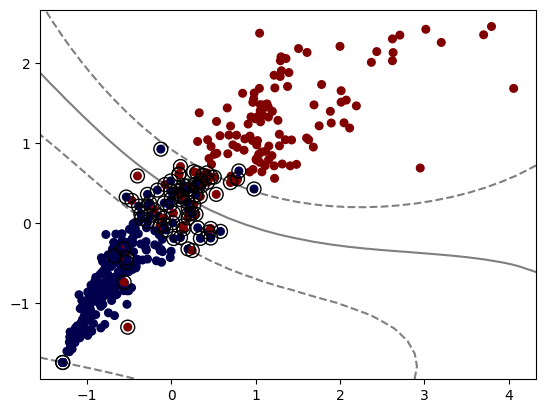

In [74]:
plot_svm_boundary(best_model,X_train,y_train)

In [75]:
scenarios = {
    "Case 1\n10% data, linear": {"kernel": "linear", "C": 1, "gamma": "scale", "fraction": 0.1},
    "Case 2\n100% data, linear": {"kernel": "linear", "C": 1, "gamma": "scale", "fraction": 1.0},
    "Case 3\n10% data, rbf": {"kernel": "rbf", "C": 1, "gamma": 0.01, "fraction": 0.1},
    "Case 4\n100% data, rbf": {"kernel": "rbf", "C": 1, "gamma": 0.01, "fraction": 1.0}
}


In [80]:
train_times = []
predict_times = []

for case, params in scenarios.items():
    n_samples = int(len(X_train) * params["fraction"])
    X_sub, y_sub = X_train[:n_samples], y_train[:n_samples]

    model = SVC(kernel=params["kernel"], C=params["C"], gamma=params["gamma"])

    start = time.time()
    model.fit(X_sub, y_sub)
    end = time.time()
    train_time = end - start

    start = time.time()
    _ = model.predict(X_val)
    end = time.time()
    predict_time = end - start

    train_times.append(train_time)
    predict_times.append(predict_time)


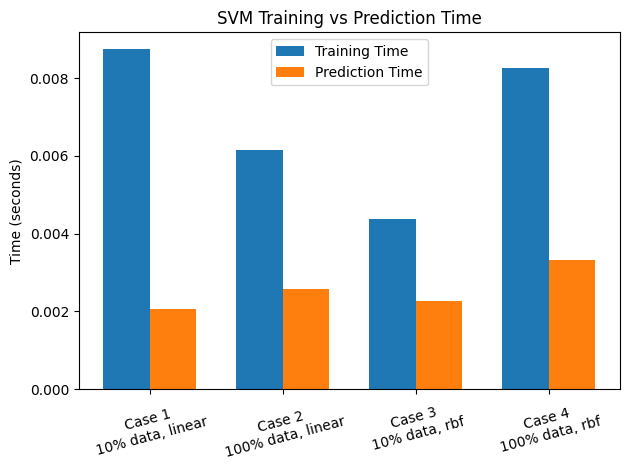

In [81]:
x = np.arange(len(scenarios))
width = 0.35

plt.bar(x - width/2, train_times, width, label="Training Time")
plt.bar(x + width/2, predict_times, width, label="Prediction Time")

plt.xticks(x, scenarios.keys(), rotation=15)
plt.ylabel("Time (seconds)")
plt.title("SVM Training vs Prediction Time")
plt.legend()
plt.tight_layout()
plt.show()


In [82]:
X_overlap = X_train.copy()
y_overlap = y_train.copy()

In [86]:
X_overlap['concave points_mean'] = X_overlap['concave points_mean'] * 0.5
X_overlap['concave points_worst'] = X_overlap['concave points_worst'] * 0.5


In [87]:
svm_clean = SVC(kernel="rbf", C=1, gamma=0.01)
svm_clean.fit(X_train, y_train)

SVC(C=1, gamma=0.01)

In [88]:
svm_overlap = SVC(kernel="rbf", C=1, gamma=0.01)
svm_overlap.fit(X_overlap, y_overlap)


SVC(C=1, gamma=0.01)

In [89]:
acc_clean = accuracy_score(y_val, svm_clean.predict(X_val))
acc_overlap = accuracy_score(y_val, svm_overlap.predict(X_val))

print("Accuracy with clean data:", acc_clean)
print("Accuracy with overlapping classes:", acc_overlap)
print("Performance drop:", acc_clean - acc_overlap)

Accuracy with clean data: 0.92
Accuracy with overlapping classes: 0.91
Performance drop: 0.010000000000000009


In [90]:
rng = np.random.RandomState(42)

X_noisy = X_train.copy()
n_noisy = int(0.1 * X_noisy.shape[0])
indices = rng.choice(X_noisy.shape[0], n_noisy, replace=False)


In [92]:
X_noisy.iloc[indices] += rng.normal(0, 0.5, X_noisy.iloc[indices].shape)

In [93]:
svm_noisy = SVC(kernel="rbf", C=1, gamma=0.01)
svm_noisy.fit(X_noisy, y_train)

SVC(C=1, gamma=0.01)

In [94]:
acc_val_noisy = accuracy_score(y_val, svm_noisy.predict(X_val))
acc_test_noisy = accuracy_score(y_test, svm_noisy.predict(X_test))

print("Validation accuracy with noisy data:", acc_val_noisy)
print("Test accuracy with noisy data:", acc_test_noisy)

Validation accuracy with noisy data: 0.92
Test accuracy with noisy data: 0.9565217391304348
